# 04 — The new programme

**Fifth of five.** `02-ext-research/`: what the findings produced, and where it
currently stands.

Notebooks 01–03 established that the standard benchmark cannot answer the
question it is asked. This notebook is about what was done next, and it is held
to the standard the previous three applied to other people's work. That means the
failures get the same space as the successes:

- **P0's gate failed**, and the reason forced a **pre-registered hypothesis to be
  amended** — on the record, as a new numbered entry. §4 shows that as a process,
  because it is a model of how it should be done.
- **The datasaurus gate caught a real bug on day one** that an elementwise check
  passed straight through. §3 reproduces it live.
- **P2's H1 passed both of its clauses**, **and** the burstiness floor was **not
  cleared**, **and** the rendered α-curves do not demonstrate H1's stated
  mechanism. §6 reports all three, in that order, with equal weight.

Two things this project is explicitly **not** about, stated once at the top:
it is not about AI-generated text (every corpus is 2015–2022 and carries no
ground truth for machine-generated text — `docs/00-CHARTER.md` §4, non-goal 1),
and it is not a claim that the three papers are wrong.

### Running this notebook

Pinned to the kernel `ext-research` — the `.venv` beside the project. Register it
once, from the repository root:

```bash
02-ext-research/.venv/bin/python -m ipykernel install \
    --user --name ext-research --display-name "Python (02-ext-research)"
```

**It runs on a clean checkout with no data and no results.** `.gitignore` excludes
`results/` at every level, and the corpora are gigabytes behind author
applications, so nothing here reads `data/` or `results/`. Measured numbers are
**hard-coded as verified constants** in the cell below, each carrying the file it
came from and the line of
`01-info-propagation/overview/EVIDENCE-INDEX.md` that records it. Everything else
is computed live on synthetic data, in front of you.

The notebook is a **build artefact** of `scripts/build_ext_04_notebook.py`.
Edit the builder, not the `.ipynb`, or your changes are lost on the next
regeneration.

In [1]:
# --- Setup -----------------------------------------------------------------
# OMP_NUM_THREADS must be set BEFORE the first scikit-learn / numpy-BLAS import.
# On this machine the default OpenMP pool cost 133x wall time on a 4,770 x 12
# fit -- pure scheduling overhead, measured in bitacora/04_p2_temporal.md sect. 6.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

SEED = 42

# --- Palette ---------------------------------------------------------------
# One palette across all five notebooks. Colour-blind safe: validated with the
# dataviz skill's checker (worst adjacent-pair CVD delta-E 9.1, normal-vision
# 22.9, both above their floors). Hues are assigned in fixed slot order and
# never cycled; colour never carries identity alone -- every series is also
# labelled directly or in a legend.
C = {
    "blue":    "#2a78d6",   # slot 1 -- the thing under test
    "orange":  "#eb6834",   # slot 2 -- its comparison / the other class
    "aqua":    "#1baf7a",   # slot 3 -- a third series
    "yellow":  "#eda100",   # slot 4
    "magenta": "#e87ba4",   # slot 5
    "violet":  "#4a3aa7",   # slot 6
    "red":     "#e34948",   # reserved: floors, baselines, failures
    "grey":    "#8a8a86",   # recessive: grids, noise bands, context
    "ink":     "#0b0b0b",
}
SERIES = [C["blue"], C["orange"], C["aqua"], C["yellow"], C["magenta"], C["violet"]]

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c9c9c4", "axes.labelcolor": C["ink"],
    "axes.grid": True, "grid.color": "#e3e3de", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": C["ink"],
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "legend.frameon": False, "lines.linewidth": 2.0,
})

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True, linewidth=110)

print(f"numpy {np.__version__} | pandas {pd.__version__} | matplotlib {mpl.__version__}")
print(f"OMP_NUM_THREADS={os.environ['OMP_NUM_THREADS']}  seed={SEED}")

numpy 2.5.2 | pandas 3.0.5 | matplotlib 3.11.1
OMP_NUM_THREADS=1  seed=42


In [2]:
# --- The one notebook that imports the project's own package ---------------
# ONLY the pure estimator functions: spectrum.py and generators.py depend on
# numpy alone and read no data, no corpus and no results. Verify that here
# rather than trusting it -- this notebook has to run on a clean checkout.
import sys
from pathlib import Path

# Walk up from the working directory until the repository root is found, so the
# notebook works whether Jupyter was started here or at the root.
root = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
            if (p / "renyiext" / "spectrum.py").exists())
sys.path.insert(0, str(root))
print("repository root:", root)

from renyiext.spectrum import renyi_entropy, spectrum, spectrum_labels, \
                              counts_to_probabilities, log_bin_counts, \
                              SPECTRUM_ALPHAS
from renyiext.generators import (periodic_account, poisson_account,
                                 bursty_account, generate_control_set)

print("imported renyiext.spectrum and renyiext.generators")
print("alphas in the standard spectrum:", spectrum_labels(SPECTRUM_ALPHAS))

repository root: /Users/alberto/Documents/projects/renyi
imported renyiext.spectrum and renyiext.generators
alphas in the standard spectrum: ['H_0', 'H_0.5', 'H_1', 'H_2', 'H_4', 'H_inf']


---

## 1. From five findings to one design

Taken one at a time, F1–F5 read as criticisms of three papers. Taken together
they describe a single structural problem, in four steps:

**(a) There is no headroom.** Cresci-2015 under 5-fold CV saturates at **0.9779**
with a fold σ of **0.0063**, and five metadata numbers with an MLP already reach
**0.9775**. A new feature has ~0.002 of room against 0.006 of noise; any result
measured there is unfalsifiable.

**(b) The features that carry the result are the brittle ones.** What does the
work is metadata *magnitude* — follower counts, tweet counts, account age.
Follower counts are purchasable; account age is era-specific.

**(c) And their brittleness is already measurable.** F5(a) is the symptom: the
same five features lose **9.2 points** under a mild shift toward quieter accounts
*within one corpus*, and split membership is predictable from them at AUC 0.79.

**(d) The evidential standard in the area is too weak to detect this.** F3 and
F4: an α effect of 0.022 reported without error bars against a measured σ of
0.0179; a central novelty at +0.0035, p = 0.625 against its own ablation. F5(b):
eight of eight published rows below a majority baseline nobody computed.

So the gap is not "a better classifier on Cresci-2015". It is **features that
describe the *shape* of behaviour rather than its *magnitude*, evaluated under a
protocol that can actually detect whether they transfer.**

Each finding maps to a specific design decision. This table is the argument of
the whole series compressed into six rows.

| Finding | Design consequence |
|---|---|
| **F1** — no headroom | Within-corpus accuracy is **diagnostic only**. The primary claim (H4) is **cross-dataset transfer**: fit on Cresci-2015, test on TwiBot-20, compare *degradation* per feature family. |
| **F2** — 128 dims of rank 10 | Every estimator must satisfy stated **properties checked in code** (`renyiext/checks.py`), not merely produce a number. Rank, invariance and limiting cases are asserted. |
| **F3** — α inside noise | **The spectrum is not tuned over α.** The whole vector $[H_0, H_{1/2}, H_1, H_2, H_4, H_\infty]$ is the feature. Tuning α is one-dimensional feature selection with a multiple-comparisons hazard, and F3 showed what that search finds when there is nothing there. |
| **F4** — novelty vs its own ablation | Every claim carries **≥10 seeds and a paired Wilcoxon**, and an effect below **0.02 AUC** is not claimed *regardless of p* — 0.02 being the measured seed σ. |
| **F5** — protocol and floors | Three protocols are **named and never mixed**. A **majority baseline** is printed beside every accuracy. Seven **mandatory floors** must be beaten before any claim, including the incumbent metadata features. |

Note the third row carefully: **F3 is used as a constraint on our own design, not
as a licence.** The project does not get to tune α and report the best one,
because it just spent three notebooks explaining why that is not evidence.

---

## 2. The four pre-registered hypotheses

Written **before** any experiment, so they cannot be retrofitted to whatever the
data shows. Each states a direction, a threshold, and a test. Thresholds come
from the measured noise floors, not from taste.

**H1 — the spectrum beats its own α = 1 point, and beats volume.**
On the temporal front, the 6-vector $H_\alpha$ must clear **both** floors:
$\mathrm{AUC}(\mathrm{SPEC}_T \cup \{\text{count}\}) - \mathrm{AUC}(\text{count}) > 0.02$
and
$\mathrm{AUC}(\mathrm{SPEC}_T) - \mathrm{AUC}(H_1) > 0.02$,
each by paired Wilcoxon over ≥10 seeds at p < 0.05.
*Rationale:* human inter-event times are bursty and heavy-tailed (Barabási 2005);
scheduled bots are Poisson or periodic. These regimes differ **specifically in
the tail**, which is what α resolves and what α = 1 averages over.
*(This is the amended form. §4 explains why, and what it replaced.)*

**H2 — the discrimination is tail-directional, not arbitrary.** Bots show higher
collision probability (lower $H_2$) on behavioural-alphabet and mention-target
distributions, and lower support richness (lower $H_0$) on client-source
distributions, both at p < 0.05.

**H3 — algorithmic mutual information detects coordination.** Within-group NCD
cohesion over "digital DNA" behavioural strings separates bot groups from human
groups at AUC > 0.75, and exceeds what $H_2$ on the same strings achieves by
more than 0.02.

**H4 — generalisation (the primary claim).** Transferring Cresci-2015 →
TwiBot-20, the AUC degradation of spectrum + algorithmic-information features is
smaller than that of the five metadata features by more than **0.05**.

**H0 — the null is a publishable outcome.** If H1–H4 all fail, the result is a
negative finding with a measured effect size and a clear precedent. *This project
does not require a positive result to be worth completing.*

### And the standard of evidence

Non-negotiable, inherited from the findings:

- **≥10 seeds and a paired Wilcoxon** for every comparison. Single-run numbers
  are not reportable.
- **Majority baseline printed beside every accuracy.** Always.
- **Floors before ceilings.** A new feature must beat majority, the five metadata
  features, Shannon-only, gzip compression ratio, and block entropy *before* any
  claim is made about it.
- **TPR at FPR = 1% reported alongside AUC.** Suspending a real user is the
  operational cost of a false positive, and AUC hides the low-FPR regime where
  deployment happens.
- **Protocol stated with every number.**

---

## 3. The datasaurus gate, and the bug it caught on day one

The project adopted a standing rule from two sibling programmes, stated as a law:

> **No claim of agreement or difference enters any document until the objects it
> is about have been rendered in a common coordinate and compared elementwise.**

Four gates: **G1 RENDER** (draw the object at full length before the number
exists), **G2 ELEMENTWISE** (compare elements, not counts), **G3 KNOBS** (print
every fitted parameter and check it is interior to its bracket), **G4 MECHANISM**
(what would this number be under a process known to contain nothing?).

This sounds like boilerplate. On the first day it caught a real bug, and the way
it caught it is the best argument in the repository for rendering before quoting.

### The situation

Cresci-2015 was believed to carry no tweet timestamps. It turns out they are
recoverable: Twitter **snowflake** IDs encode milliseconds in their top 41 bits.

```
timestamp_ms = (tweet_id >> 22) + 1288834974657
```

The kick-off entry supported this with "200,000 decoded, 0 failures, range
2010-11-04 → 2013-06-03". Counts and a range. Both true, and both hiding a bug.

**Tweet IDs issued *before* 2010-11-04 are sequential counters, not snowflakes.**
They carry no time information at all — but they are large numbers (~3 × 10¹⁰),
so they survive a naive `id >= 2**22` guard and decode to a few milliseconds past
the snowflake epoch. **63,830 tweets — 2.26% of the corpus — all landed on a
single millisecond.**

Now the part that matters. Let us reproduce the situation and run the two checks
in the order they were actually run.

In [3]:
# --- Live: the snowflake decode, with the pre-snowflake ids left in --------
SNOWFLAKE_EPOCH_MS = 1_288_834_974_657        # 2010-11-04T01:42:54Z
FIRST_SNOWFLAKE_ID = 29_700_859_247           # decision D9: a value, not a bit width

def decode(tweet_id):
    """Snowflake -> unix ms. Meaningless for ids issued before the epoch."""
    return (np.asarray(tweet_id, dtype=np.int64) >> 22) + SNOWFLAKE_EPOCH_MS

gsim = np.random.default_rng(SEED)
N_GOOD, N_LEGACY = 100_000, 2_260            # 2.26%, the measured proportion

# Real snowflake ids: uniform over a two-and-a-half year window.
t0 = SNOWFLAKE_EPOCH_MS + 300 * 86_400_000
t1 = SNOWFLAKE_EPOCH_MS + 1_100 * 86_400_000
# Give them a circadian rhythm, because real posting has one.
day_ms = 86_400_000
base = gsim.uniform(t0, t1, N_GOOD)
hour_shift = (gsim.normal(20, 4.5, N_GOOD) % 24) * 3_600_000
good_ms = (base - base % day_ms) + hour_shift
good_ids = ((good_ms - SNOWFLAKE_EPOCH_MS).astype(np.int64) << 22) | gsim.integers(0, 1 << 22, N_GOOD)

# Pre-snowflake sequential ids: large, but NOT timestamps.
legacy_ids = gsim.integers(2 * 10**10, FIRST_SNOWFLAKE_ID, N_LEGACY)

ids = np.concatenate([good_ids, legacy_ids])
ts  = decode(ids)

print(f"ids to decode                : {len(ids):,}")
print(f"decode failures              : 0")
print(f"range                        : "
      f"{pd.to_datetime(ts.min(), unit='ms').date()} -> "
      f"{pd.to_datetime(ts.max(), unit='ms').date()}")
print()
print("Everything above is a COUNT and a RANGE. Both look fine. Both are.")

ids to decode                : 102,260
decode failures              : 0
range                        : 2010-11-04 -> 2013-11-08

Everything above is a COUNT and a RANGE. Both look fine. Both are.


In [4]:
# --- G2 ELEMENTWISE: check every decoded time against an independent field -
# The account's own created_at never passed through the decoder, so
# "no tweet predates its account" is a genuine, independent elementwise check.
# Give every tweet an account created in 2007-2009, as in the real corpus.
created_at = gsim.uniform(
    pd.Timestamp("2007-01-01").value // 10**6,
    pd.Timestamp("2009-12-31").value // 10**6, len(ids))

violations = int((ts < created_at).sum())
print(f"G2, elementwise: tweets decoding to a time BEFORE their account existed")
print(f"  violations: {violations} / {len(ids):,}")
print()
print("ZERO violations. The check passes.")
print("It also passed BEFORE the bug was fixed, and after -- because the fake")
print("timestamps are 2010, and the accounts were created 2007-2009, so every")
print("one of them satisfies ts >= created_at.  G2 CANNOT see this bug.")

G2, elementwise: tweets decoding to a time BEFORE their account existed
  violations: 0 / 102,260

ZERO violations. The check passes.
It also passed BEFORE the bug was fixed, and after -- because the fake
timestamps are 2010, and the accounts were created 2007-2009, so every
one of them satisfies ts >= created_at.  G2 CANNOT see this bug.


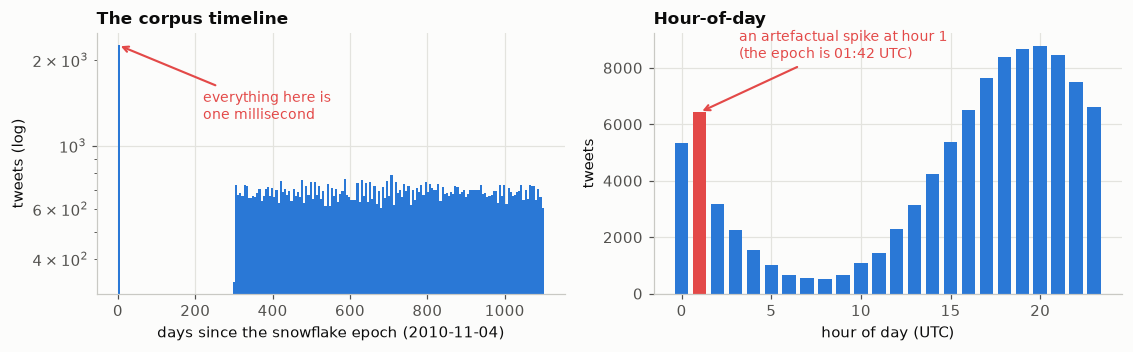

In [5]:
# --- G1 RENDER: draw the object at full length -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.3))

ax = axes[0]
days = (ts - SNOWFLAKE_EPOCH_MS) / 86_400_000.0
ax.hist(days, bins=200, color=C["blue"])
ax.set_yscale("log")
ax.annotate("everything here is\none millisecond",
            xy=(0, N_LEGACY), xytext=(220, N_LEGACY * 0.55),
            fontsize=9, color=C["red"],
            arrowprops=dict(arrowstyle="->", color=C["red"], lw=1.4))
ax.set_xlabel("days since the snowflake epoch (2010-11-04)")
ax.set_ylabel("tweets (log)")
ax.set_title("The corpus timeline")

ax = axes[1]
hours = ((ts % 86_400_000) / 3_600_000).astype(int)
counts = np.bincount(hours, minlength=24)
ax.bar(np.arange(24), counts, color=C["blue"], width=0.75)
ax.bar([1], [counts[1]], color=C["red"], width=0.75)
ax.annotate("an artefactual spike at hour 1\n(the epoch is 01:42 UTC)",
            xy=(1, counts[1]), xytext=(3.2, counts.max() * 0.95),
            fontsize=9, color=C["red"],
            arrowprops=dict(arrowstyle="->", color=C["red"], lw=1.4))
ax.set_xlabel("hour of day (UTC)"); ax.set_ylabel("tweets")
ax.set_title("Hour-of-day")
plt.tight_layout(); plt.show()

**Figure 1.** The reader should conclude that the elementwise check and the
picture are **not substitutes**. G2 reported 0 violations out of 2.76 million and
was correct to; the spike at day 0 and the hour-1 artefact were visible
immediately, and were invisible to any count.

In the real run both artefacts sat exactly at the snowflake epoch,
2010-11-04T01:42:54Z, and the id distribution confirmed the cause with a clean
four-order-of-magnitude gap and nothing in it:

```
largest sub-threshold id     29,700,661,919   -> 2010-11-04 01:43:01
smallest snowflake       292,906,606,796,800  -> 2010-11-04 21:06:49
```

**Decision D9:** the threshold is the *first snowflake id* (29,700,859,247), not
a bit width. The exclusion is carried per account, because it is class-dependent
— older accounts lose more.

In [6]:
# --- After the fix, and G4: what would this look like under a counter? -----
keep = ids >= FIRST_SNOWFLAKE_ID
ts_ok = ts[keep]
print(f"dropped: {(~keep).sum():,} of {len(ids):,} = {(~keep).mean():.2%}")
print(f"the real corpus: 63,830 of 2,827,757 = 2.26%, leaving 2,763,927 events\n")

# G4 MECHANISM. Name in advance a world in which the null separates: if the top
# 41 bits were a COUNTER rather than a clock, hour-of-day would be uniform.
def circadian_stats(t):
    h = np.bincount(((t % 86_400_000) / 3_600_000).astype(int), minlength=24)
    p = h / h.sum()
    return 0.5 * np.abs(p - 1/24).sum(), p.max() / p.min()   # total variation, peak/trough

counter_ids = np.sort(gsim.integers(0, 1 << 41, len(ts_ok))) << 22
tv_d, pt_d = circadian_stats(ts_ok)
tv_n, pt_n = circadian_stats(decode(counter_ids))

G4 = pd.DataFrame([("decoded timestamps", tv_d, pt_d, 0.2248, 12.82),
                   ("counter null",       tv_n, pt_n, 0.0002, 1.00)],
                  columns=["object", "TV (here)", "peak/trough (here)",
                           "TV (measured)", "peak/trough (measured)"])
print(G4.round(4).to_string(index=False))
print()
print("The world named in advance as separating did separate. D1 stands.")
print("The measured circadian shape is independently plausible: trough 03-05 UTC,")
print("peak 20-22 UTC -- for a largely Italian corpus (CET) that is 04-06 and 21-23")
print("local, which is when people sleep and when they post.")

dropped: 2,260 of 102,260 = 2.21%
the real corpus: 63,830 of 2,827,757 = 2.26%, leaving 2,763,927 events

            object  TV (here)  peak/trough (here)  TV (measured)  peak/trough (measured)
decoded timestamps     0.3166             16.3974         0.2248                   12.82
      counter null     0.0079              1.0757         0.0002                    1.00

The world named in advance as separating did separate. D1 stands.
The measured circadian shape is independently plausible: trough 03-05 UTC,
peak 20-22 UTC -- for a largely Italian corpus (CET) that is 04-06 and 21-23
local, which is when people sleep and when they post.


**The transferable lesson, and it is the fifth of five in the overview
documents:** *look at the object before quoting a statistic of it.* The single
biggest error caught in this project was invisible to an elementwise check that
passed at 0 violations, and visible immediately in a histogram.

---

## 4. P0 — the gate that failed, and the amendment that followed

P0's job was to build the event layer and pass gate **G0**. It failed G0 — not on
the decode, which stood, but on the `n_events` criterion. The reason changed the
design, and the way that change was made is worth as much as the result.

### 4.1 A datasaurus of the project's own

The kick-off entry reported "~533 tweets per user". That is the **mean** over a
bimodal distribution. The median is **38**, and the per-class picture is what
matters.

In [7]:
# --- Verified constants: P0's per-class event counts -----------------------
# Source: 02-ext-research/bitacora/01_p0_data_layer.md sect. 2.1, from
# results/p0_events.json. Cresci-2015 after decision D9.
COUNTS = pd.DataFrame([
    ("25th percentile",   16,   237),
    ("median",            23,   834),
    ("75th percentile",   38, 2_551),
    ("90th percentile",   63, 3_193),
    ("mean",              55, 1_322),
], columns=["quantile", "bot", "human"])
print("Decodable events per account, Cresci-2015 (5,301 users, 2,763,927 events)\n")
print(COUNTS.to_string(index=False))
print()
print("196 bots have ZERO decodable events; 4 humans do.")
print("The human mass near 3,200 is the Twitter API's per-user timeline cap,")
print("not behaviour -- a ceiling in the collection, not in the accounts.")
print()
print("Note the direction: bots are the LOW-volume class here, which is the")
print("opposite of the usual assumption.")

Decodable events per account, Cresci-2015 (5,301 users, 2,763,927 events)

       quantile  bot  human
25th percentile   16    237
         median   23    834
75th percentile   38   2551
90th percentile   63   3193
           mean   55   1322

196 bots have ZERO decodable events; 4 humans do.
The human mass near 3,200 is the Twitter API's per-user timeline cap,
not behaviour -- a ceiling in the collection, not in the accounts.

Note the direction: bots are the LOW-volume class here, which is the
opposite of the usual assumption.


### 4.2 And the consequence: volume is the dominant signal

**AUC of event count alone = 0.939.** One feature. It is already present in the
metadata block as `tweet_count`.

This is the project's own risk R1 realised, and worse than anticipated. It is not
that an uncorrected spectrum *might* encode volume; it is that volume is worth
0.939 here, so **anything correlated with it will look excellent**.

### 4.3 The planned control turned out to be unexecutable

The pre-registered design (decision D3) controlled for this by **fixed-n
subsampling**: take exactly $n$ events per account, so the estimator's
sample-size bias becomes a constant offset. Gate G0 required ≥80% of accounts
retained **in both classes**.

In [8]:
# --- Verified constants: the fixed-n retention sweep -----------------------
# Source: bitacora/01_p0_data_layer.md sect. 2.3. All 13 swept values of
# n_events were reported there; the six that decide the gate are shown.
RETENTION = pd.DataFrame([
    (8,  0.829, 0.981), (12, 0.808, 0.973), (16, 0.751, 0.969),
    (32, 0.314, 0.941), (64, 0.097, 0.900), (128, 0.043, 0.833),
], columns=["n", "kept_bot", "kept_human"])
RETENTION["gate_G0_met"] = (RETENTION.kept_bot >= 0.8) & (RETENTION.kept_human >= 0.8)
RETENTION["H0_ceiling_bits"] = np.log2(RETENTION.n)
print(RETENTION.to_string(index=False))
print()
print("G0 (>=80% retained in BOTH classes) is met only at n <= 12.")
print("But a Rényi spectrum on 12 events is not a measurement: H_0 <= log2(12)")
print("= 3.58 bits, and every order is bias-dominated.")
print()
print("Raise n to where the spectrum is meaningful (>=64) and 90% of the bot class")
print("is discarded -- non-randomly, keeping exactly the atypical high-volume bots.")
print()
print("The two requirements are in DIRECT CONFLICT on this corpus.")
print("That is a property of the corpus, and no amount of tuning dissolves it.")

  n  kept_bot  kept_human  gate_G0_met  H0_ceiling_bits
  8     0.829       0.981         True         3.000000
 12     0.808       0.973         True         3.584963
 16     0.751       0.969        False         4.000000
 32     0.314       0.941        False         5.000000
 64     0.097       0.900        False         6.000000
128     0.043       0.833        False         7.000000

G0 (>=80% retained in BOTH classes) is met only at n <= 12.
But a Rényi spectrum on 12 events is not a measurement: H_0 <= log2(12)
= 3.58 bits, and every order is bias-dominated.

Raise n to where the spectrum is meaningful (>=64) and 90% of the bot class
is discarded -- non-randomly, keeping exactly the atypical high-volume bots.

The two requirements are in DIRECT CONFLICT on this corpus.
That is a property of the corpus, and no amount of tuning dissolves it.


### 4.4 The amendment, as a process

Here is the part to copy.

The hypotheses were **pre-registered** precisely so they could not be retrofitted.
So the response was not to quietly change H1. It was to:

1. **Record the failure** in the bitácora (`01_p0_data_layer.md`), with the
   numbers, as a **FAIL**;
2. **State the options** — (a) reframe H1 as incremental over volume, (b) a
   volume-matched subpopulation, (c) move the primary front to another corpus —
   with the cost of each, and a recommendation;
3. **Not decide unilaterally**;
4. **Record the decision as a new numbered entry** (`02_h1_amendment.md`) that
   says what it supersedes. The superseded entries **stay where they are,
   unedited**.

| | statement |
|---|---|
| **H1, superseded** | $\mathrm{AUC}(H_\alpha) - \mathrm{AUC}(H_1) > 0.02$ at fixed n = 128 |
| **H1, in force from 2026-08-18** | variable n; clear **both** $\mathrm{AUC}(\mathrm{SPEC}_T \cup \{\text{count}\}) - \mathrm{AUC}(\text{count}) > 0.02$ **and** $\mathrm{AUC}(\mathrm{SPEC}_T) - \mathrm{AUC}(H_1) > 0.02$ |

**The amended hypothesis is *harder*, not easier.** The charter's own motivation
is that metadata magnitude is brittle and shape should transfer. Event count *is*
magnitude. Requiring the spectrum to beat it directly is the sharper form of the
question the project was always asking — and it is more dangerous, because at
AUC 0.939 count is a brutal floor.

That last sentence is the test of whether an amendment is honest: **an amendment
that makes your hypothesis easier to pass is a different thing entirely.**

Three controls replaced what fixed-n was providing: count is a **mandatory
covariate** in every model and table; **partial correlation** $\rho(H_\alpha,
\text{label} \mid \text{count})$ is reported beside the raw correlation; and a
**positive control at matched n** — synthetic accounts with known generators and
**identical event counts**. That last one is what actually rescues the design,
and it is checkable without touching the corpus, so you can run it here.

---

## 5. P1 — the estimator, and a warning recorded before it could be rationalised

P1 built the Rényi spectrum estimator and passed gate **G1**: 8 of 8 properties.
The properties are the F2 discipline applied to ourselves — an estimator must
satisfy stated mathematical properties, not merely produce a number.

Let us check three of them live, using the project's actual code.

In [9]:
# --- Three of the eight properties, checked against renyiext.spectrum ------
alphas = SPECTRUM_ALPHAS
print("P1 -- uniform gives log2(n) for EVERY order:")
for n in (2, 5, 17, 128):
    p = np.ones(n) / n
    err = max(abs(renyi_entropy(p, a) - np.log2(n)) for a in alphas)
    print(f"    n = {n:>4}   max |H_alpha - log2 n| = {err:.2e}")

print("\nP3 -- H_alpha is non-increasing in alpha (300 random distributions):")
gp = np.random.default_rng(0)
worst = 0.0
for _ in range(300):
    p = gp.dirichlet(np.ones(gp.integers(2, 40)))
    s = spectrum(p, alphas)
    worst = max(worst, float(np.max(np.diff(s))))
print(f"    largest increase found: {worst:.2e}   (must be <= 0)")

print("\nP4 -- H_inf <= H_2 <= H_1 <= H_0 <= log2|support|:")
p = gp.dirichlet(np.ones(25))
s = dict(zip(spectrum_labels(alphas), spectrum(p, alphas)))
print("   ", {k: round(v, 4) for k, v in s.items()})
print(f"    log2|support| = {np.log2(25):.4f}")

P1 -- uniform gives log2(n) for EVERY order:
    n =    2   max |H_alpha - log2 n| = 0.00e+00
    n =    5   max |H_alpha - log2 n| = 4.44e-16
    n =   17   max |H_alpha - log2 n| = 8.88e-16
    n =  128   max |H_alpha - log2 n| = 8.88e-16

P3 -- H_alpha is non-increasing in alpha (300 random distributions):
    largest increase found: 0.00e+00   (must be <= 0)

P4 -- H_inf <= H_2 <= H_1 <= H_0 <= log2|support|:
    {'H_0': np.float64(4.6439), 'H_0.5': np.float64(4.2721), 'H_1': np.float64(4.0211), 'H_2': np.float64(3.7047), 'H_4': np.float64(3.3902), 'H_inf': np.float64(2.8149)}
    log2|support| = 4.6439


### 5.1 A defect the checks caught: catastrophic cancellation at α = 1

Property P2 requires $H_\alpha$ to be continuous at α = 1 to within 1e-9. The
closed form $\frac{1}{1-\alpha}\log_2\sum p^\alpha$ is **ill-conditioned** there:
the log tends to 0 while the prefactor tends to ∞, so double-precision error in
the log is amplified by $1/\lvert 1-\alpha\rvert$.

The fix was a series expansion, **not a widened tolerance**:

$$H_\alpha \;=\; H_1 \;-\; (\alpha-1)\,\frac{\operatorname{Var}_p[\ln p]}{2\ln 2} \;+\; O((\alpha-1)^2)$$

exact at α = 1, first-order accurate around it, switched in for
$\lvert 1-\alpha \rvert < 10^{-6}$. Watch both versions fail and succeed.

In [10]:
# --- The naive closed form vs the shipped estimator, near alpha = 1 --------
def renyi_naive(p, alpha):
    """The literal formula. Correct on paper; unusable near alpha = 1."""
    p = np.asarray(p, float); p = p[p > 0]; p = p / p.sum()
    return float(np.log2((p ** alpha).sum()) / (1.0 - alpha))

gq = np.random.default_rng(1)
p = gq.dirichlet(np.ones(50))
h1 = renyi_entropy(p, 1.0)

rows = []
for d in (1e-3, 1e-5, 1e-7, 1e-9, 1e-11):
    rows.append((d, abs(renyi_naive(p, 1.0 + d) - h1),
                    abs(renyi_entropy(p, 1.0 + d) - h1)))
NEAR1 = pd.DataFrame(rows, columns=["|1 - alpha|", "naive closed form",
                                    "renyiext.renyi_entropy"])
print("Absolute deviation from H_1, which the true value must approach smoothly:\n")
print(NEAR1.to_string(index=False, float_format=lambda v: f"{v:.3e}"))
print()
print("The naive form's error GROWS as alpha approaches 1 -- the opposite of what")
print("continuity requires. P2's measured error after the fix: 1.04e-09 over 200")
print("simplex points (bitacora/03_p1_spectrum.md sect. 1).")

Absolute deviation from H_1, which the true value must approach smoothly:

 |1 - alpha|  naive closed form  renyiext.renyi_entropy
   1.000e-03          6.093e-04               6.093e-04
   1.000e-05          6.093e-06               6.094e-06
   1.000e-07          6.115e-08               6.093e-08
   1.000e-09          2.440e-07               6.093e-10
   1.000e-11          7.115e-06               6.094e-12

The naive form's error GROWS as alpha approaches 1 -- the opposite of what
continuity requires. P2's measured error after the fix: 1.04e-09 over 200
simplex points (bitacora/03_p1_spectrum.md sect. 1).


A second defect is recorded there too, and is worth repeating because it is the
cheap version of a real hazard: **property P4's original check was itself
buggy** — a Python chained comparison that applied its tolerance in one direction
only, failing on a 1e-15 discrepancy in the *check*, not the estimator. *A
failing check is not evidence of a failing estimator until you have read the
check.*

### 5.2 The finite-sample bias, measured rather than corrected

Property P7 measures the estimator's bias directly: draw $n$ samples from a
**fixed** distribution, so any movement of $H_\alpha$ with $n$ is estimator bias
and nothing else.

| | n = 8 → 4096 |
|---|---|
| $H_0$ drift | **+1.314 bits** |
| $H_\infty$ drift | 0.133 bits |

The bias is real, an order of magnitude worse at small α, and Cresci-2015's
per-account n ranges from 0 to ~3,200. It is **reported and controlled by
conditioning on count, not corrected** — there is no standard correction for
general α comparable to Chao–Shen at α = 1, so pretending to one would be worse
than stating the bias.

**This is the number that justifies making count a mandatory covariate.**

### 5.3 The warning P1 recorded before P2 ran

The positive control (standing rule S4.2) generates synthetic accounts from three
known processes at **matched event counts**: periodic (a cron job), Poisson (a
randomised scheduler), heavy-tailed (human bursts). If the spectrum cannot
separate those at equal n, it is reading volume, not shape.

The first version of that control used easy settings and returned **1.000** — and
**Shannon alone also returned 1.000**. A control that everything passes licenses
nothing. So the difficulty was swept, and the result was recorded as a standing
warning against the project's own hypothesis:

| periodic jitter | Pareto tail | spectrum | Shannon alone | gain |
|---|---|---|---|---|
| 0.02 | 1.2 | 0.997 | 1.000 | **−0.003** |
| 0.50 | 1.2 | 0.925 | 0.911 | **+0.014** |
| 1.00 | 2.0 | 0.953 | 0.947 | **+0.006** |
| 1.50 | 3.0 | 0.939 | 0.939 | **+0.000** |
| 2.00 | 5.0 | 0.933 | 0.947 | **−0.014** |

*(3-class synthetic, matched n = 200, 5-fold CV; chance = 0.333.
`bitacora/03_p1_spectrum.md` §4.)*

**Across the whole difficulty range the gain is within ±0.014 — inside the 0.02
effect-size floor, and negative at both ends.** And this is on data *engineered
to have exactly the mechanism H1 postulates*.

The bitácora records this **before P2 ran**, so it could not be rationalised
afterwards, and notes that it is the DTWRE α-flatness reappearing on a second,
unrelated substrate. It also records the honest counter-arguments: different task
and readout, an unswept log-binning grid, and real accounts being mixtures rather
than pure processes.

Note the discipline in the last line of that entry: *"P8′ therefore reports the
gain rather than asserting it. A check must not assert the hypothesis it exists
to make testable."*

---

## 6. P2 — the temporal front, and the test of H1

Gate G2. 10 seeds (42–51), 5-fold stratified CV, gradient-boosted trees, two runs
agreeing to the digit.

Following the bitácora's own structure, the interpretation is **split into three
parts**, so that a partial success cannot be read as the whole one. §6.1 is what
passed. §6.2 is what did not. §6.3 is what the picture says about the mechanism,
and it is not what H1 claims.

### The sample, first

`min_events = 5` on 5,301 accounts leaves **n = 4,770** (2,846 bot, 1,924 human).
Excluded: **505 bot, 26 human** — severely class-dependent, as P0 predicted,
removing the least active bots. The **majority baseline falls from 0.6321 to
0.5966**, and every accuracy below is against that number. At `min_events = 2`
(n = 4,994) the headline difference is unchanged at +0.0369, so the exclusion is
not driving the result.

## 6.1 What passed

In [11]:
# --- Verified constants: P2 arms -------------------------------------------
# Source: 02-ext-research/results/p2_temporal.json, via bitacora/04_p2_temporal.md
# sect. 2. 10 seeds (42-51), 5-fold stratified CV, HistGradientBoostingClassifier.
P2_MAJORITY = 0.5966
P2 = pd.DataFrame([
    ("COUNT",         1, 0.9400, 0.0011, 0.141, 0.912, 0.916),
    ("BURST",         3, 0.9141, 0.0013, 0.344, 0.854, 0.858),
    ("SHAN",          2, 0.9318, 0.0012, 0.489, 0.860, 0.865),
    ("SPEC_T",       12, 0.9699, 0.0007, 0.779, 0.916, 0.919),
    ("COUNT+BURST",   4, 0.9594, 0.0009, 0.520, 0.901, 0.905),
    ("COUNT+SHAN",    3, 0.9731, 0.0008, 0.792, 0.918, 0.921),
    ("COUNT+SPEC_T", 13, 0.9767, 0.0005, 0.792, 0.922, 0.925),
], columns=["arm", "dim", "auc", "auc_sd", "tpr_at_1pct_fpr", "macro_f1", "accuracy"])
P2["over_majority"] = P2.accuracy - P2_MAJORITY

print("Blocks:  COUNT = log event count (the incumbent)")
print("         BURST = CV, Goh-Barabasi burstiness B, memory M")
print("         SHAN  = Shannon only: H_1 of inter-arrival and of hour-of-day")
print("         SPEC_T= the full Renyi spectrum of both, 6 orders each")
print(f"\nn = 4,770.  MAJORITY BASELINE = {P2_MAJORITY:.4f}\n")
print(P2.to_string(index=False))

Blocks:  COUNT = log event count (the incumbent)
         BURST = CV, Goh-Barabasi burstiness B, memory M
         SHAN  = Shannon only: H_1 of inter-arrival and of hour-of-day
         SPEC_T= the full Renyi spectrum of both, 6 orders each

n = 4,770.  MAJORITY BASELINE = 0.5966

         arm  dim    auc  auc_sd  tpr_at_1pct_fpr  macro_f1  accuracy  over_majority
       COUNT    1 0.9400  0.0011            0.141     0.912     0.916         0.3194
       BURST    3 0.9141  0.0013            0.344     0.854     0.858         0.2614
        SHAN    2 0.9318  0.0012            0.489     0.860     0.865         0.2684
      SPEC_T   12 0.9699  0.0007            0.779     0.916     0.919         0.3224
 COUNT+BURST    4 0.9594  0.0009            0.520     0.901     0.905         0.3084
  COUNT+SHAN    3 0.9731  0.0008            0.792     0.918     0.921         0.3244
COUNT+SPEC_T   13 0.9767  0.0005            0.792     0.922     0.925         0.3284


In [12]:
# --- H1, both clauses ------------------------------------------------------
H1 = pd.DataFrame([
    ("(i)  COUNT+SPEC_T  -  COUNT alone", 0.0367, 0.0020, "10/10"),
    ("(ii) SPEC_T        -  SHAN alone",  0.0380, 0.0020, "10/10"),
], columns=["clause", "delta_auc", "wilcoxon_p", "wins"])
H1["floor"] = 0.02
H1["verdict"] = np.where(H1.delta_auc > 0.02, "CLEARS", "fails")
print("H1, pre-registered, paired Wilcoxon over 10 seeds:\n")
print(H1.to_string(index=False))
print()
print("H1 IS SUPPORTED AS PRE-REGISTERED. The spectrum beats event count -- the")
print("feature that scores AUC 0.939 alone and is already in the metadata block --")
print("and it beats its own alpha = 1 point.")
print()
print("Stability across the swept grid (14 configurations of n_bins, hi, min_events):")
print("  clause (i) :  +0.0350 to +0.0381  -- every configuration clears, range 0.003")
print("  clause (ii):  +0.0248 to +0.0626  -- every configuration clears, but it")
print("                DECLINES MONOTONICALLY in n_bins (0.0581 at 8 -> 0.0248 at 48)")
print()
print("The headline uses the protocol default (24 bins, 400 d, min 5), NOT the sweep")
print("argmax; selecting the argmax would be selecting on the outcome.")

H1, pre-registered, paired Wilcoxon over 10 seeds:

                           clause  delta_auc  wilcoxon_p  wins  floor verdict
(i)  COUNT+SPEC_T  -  COUNT alone     0.0367       0.002 10/10   0.02  CLEARS
 (ii) SPEC_T        -  SHAN alone     0.0380       0.002 10/10   0.02  CLEARS

H1 IS SUPPORTED AS PRE-REGISTERED. The spectrum beats event count -- the
feature that scores AUC 0.939 alone and is already in the metadata block --
and it beats its own alpha = 1 point.

Stability across the swept grid (14 configurations of n_bins, hi, min_events):
  clause (i) :  +0.0350 to +0.0381  -- every configuration clears, range 0.003
  clause (ii):  +0.0248 to +0.0626  -- every configuration clears, but it
                DECLINES MONOTONICALLY in n_bins (0.0581 at 8 -> 0.0248 at 48)

The headline uses the protocol default (24 bins, 400 d, min 5), NOT the sweep
argmax; selecting the argmax would be selecting on the outcome.


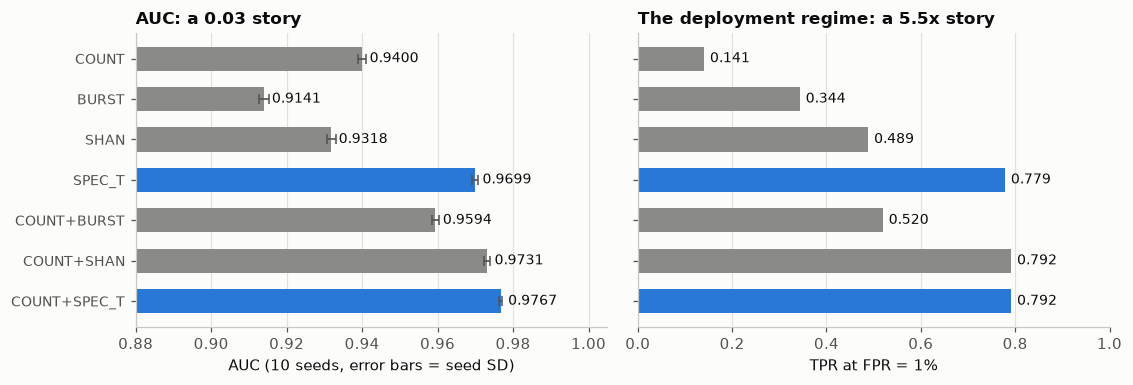

At FPR = 1%: COUNT recovers 0.141 of bots, SPEC_T recovers 0.779  -- 5.5x
majority baseline 0.5966


In [13]:
# --- Chart: AUC understates the operational difference badly ---------------
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.6))
order = ["COUNT", "BURST", "SHAN", "SPEC_T", "COUNT+BURST", "COUNT+SHAN", "COUNT+SPEC_T"]
d = P2.set_index("arm").loc[order]
cols = [C["blue"] if "SPEC_T" in a else C["grey"] for a in order]

ax = axes[0]
ax.barh(range(len(d))[::-1], d.auc, xerr=d.auc_sd, color=cols, height=0.6,
        error_kw=dict(ecolor="#52514e", capsize=3, lw=1.1))
for i, (a, v) in enumerate(zip(order, d.auc)):
    ax.text(v + 0.002, len(d) - 1 - i, f"{v:.4f}", va="center", fontsize=9)
ax.set_yticks(range(len(d))[::-1]); ax.set_yticklabels(order, fontsize=9)
ax.set_xlim(0.88, 1.005); ax.set_xlabel("AUC (10 seeds, error bars = seed SD)")
ax.set_title("AUC: a 0.03 story")
ax.grid(axis="y", visible=False)

ax = axes[1]
ax.barh(range(len(d))[::-1], d.tpr_at_1pct_fpr, color=cols, height=0.6)
for i, (a, v) in enumerate(zip(order, d.tpr_at_1pct_fpr)):
    ax.text(v + 0.012, len(d) - 1 - i, f"{v:.3f}", va="center", fontsize=9)
ax.set_yticks(range(len(d))[::-1]); ax.set_yticklabels([], fontsize=9)
ax.set_xlim(0, 1.0); ax.set_xlabel("TPR at FPR = 1%")
ax.set_title("The deployment regime: a 5.5x story")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print(f"At FPR = 1%: COUNT recovers {P2.set_index('arm').loc['COUNT','tpr_at_1pct_fpr']:.3f} "
      f"of bots, SPEC_T recovers {P2.set_index('arm').loc['SPEC_T','tpr_at_1pct_fpr']:.3f}"
      f"  -- {0.779/0.141:.1f}x")
print(f"majority baseline {P2_MAJORITY:.4f}")

**Figure 2.** The same seven arms, two metrics. On AUC the spectrum buys about
0.03 over event count. At **FPR = 1%** — the regime where deployment happens,
because the cost of a false positive is suspending a real user — it recovers
0.779 of bots against count's 0.141, a **5.5× difference**. AUC understates this
badly, which is why the protocol requires both numbers on every row.

## 6.2 What did NOT pass

In [14]:
# --- Verified constants: protocol floor 6, burstiness ----------------------
# Source: bitacora/04_p2_temporal.md sect. 3. Same 10 seeds, same protocol.
FLOOR6 = pd.DataFrame([
    ("COUNT+SPEC_T  vs  COUNT+BURST",       0.0173, 0.0020, "10/10"),
    ("COUNT+BURST+SPEC_T  vs  COUNT+BURST", 0.0192, 0.0020, "10/10"),
], columns=["comparison", "delta_auc", "wilcoxon_p", "wins"])
FLOOR6["floor"] = 0.02
FLOOR6["verdict"] = np.where(FLOOR6.delta_auc > 0.02, "clears", "FAILS")
print("Protocol floor 6 -- the burstiness floor (CV, Goh-Barabasi B, memory M).")
print("docs/02-PROTOCOL.md makes these a MANDATORY floor for the temporal front,")
print("and states that a family failing its floors is REPORTED AS FAILING.\n")
print(FLOOR6.to_string(index=False))
print()
print("Both are significant at 10/10 wins. Both sit BELOW the pre-registered 0.02")
print("effect-size floor, which the protocol says is not claimed regardless of p.")
print()
print("THE HONEST STATEMENT: twelve Renyi orders add 0.019 AUC over three classical")
print("burstiness numbers. The spectrum is NOT shown to be worth its dimensionality")
print("against the right incumbent.")

Protocol floor 6 -- the burstiness floor (CV, Goh-Barabasi B, memory M).
docs/02-PROTOCOL.md makes these a MANDATORY floor for the temporal front,
and states that a family failing its floors is REPORTED AS FAILING.

                         comparison  delta_auc  wilcoxon_p  wins  floor verdict
      COUNT+SPEC_T  vs  COUNT+BURST     0.0173       0.002 10/10   0.02   FAILS
COUNT+BURST+SPEC_T  vs  COUNT+BURST     0.0192       0.002 10/10   0.02   FAILS

Both are significant at 10/10 wins. Both sit BELOW the pre-registered 0.02
effect-size floor, which the protocol says is not claimed regardless of p.

THE HONEST STATEMENT: twelve Renyi orders add 0.019 AUC over three classical
burstiness numbers. The spectrum is NOT shown to be worth its dimensionality
against the right incumbent.


**This is the finding a reader should carry.** H1 named Shannon and count as its
floors and cleared both. The protocol named **burstiness** too, and it did not
clear that one.

And the reason is a lesson about hypothesis design, not about entropy: **H1's
clauses were the wrong comparison to make it interesting.** SHAN — two Shannon
entropies — was too weak a baseline. BURST is the baseline a referee will raise,
and it was nearly missed. It is now a first-class floor in every subsequent
front.

Notice that this is exactly F4 (notebook 02) turned on the project itself:
*beating the baselines you chose is not the test; beating the one that isolates
your contribution is.*

## 6.3 The picture disagrees with H1's stated mechanism

H1's rationale was specific: human inter-event times are bursty and heavy-tailed,
scheduled bots are Poisson or periodic, and *these regimes differ specifically in
the tail, which is what α resolves*. The datasaurus gate requires the render
before the claim — so the α-curves were drawn per class, and they do not support
that mechanism.

Three measurements, from `bitacora/04_p2_temporal.md` §4:

1. **The α-curves are near-parallel.** Bot and human inter-arrival curves are
   offset by ~1.0–1.1 bits at *every* order, with similar slope (human falls
   3.78 → 2.32, a drop of 1.46; bot 2.69 → 1.54, a drop of 1.15). If the
   separation were purely tail-resolved, the curves would **converge or cross**,
   not translate.
2. **Per-order separation is flat, and every order is below the count floor.**
   All six inter-arrival orders score $\lvert 2\cdot\mathrm{AUC}-1 \rvert$
   between 0.81 and 0.88; COUNT alone scores 0.88. **No single order beats
   volume.**
3. **Every order is substantially volume.** $\lvert\rho$ with log count$\rvert$:
   $H_0$ 0.82, $H_{0.5}$ 0.73, $H_1$ 0.70, $H_2$ 0.68, $H_4$ 0.68, $H_\infty$
   0.66. $H_0$ is the worst, which is expected —
   $H_0 = \log_2(\text{occupied bins})$ is bounded by
   $\log_2\min(n, n_{\text{bins}})$ and is therefore *mechanically* a function
   of n.

Let us render the same object on synthetic accounts, using the project's own
generators and estimator, and see the shape of the argument for ourselves.

180 synthetic accounts, 200 events EACH -> count is uninformative
generators: ['periodic', 'poisson', 'bursty']


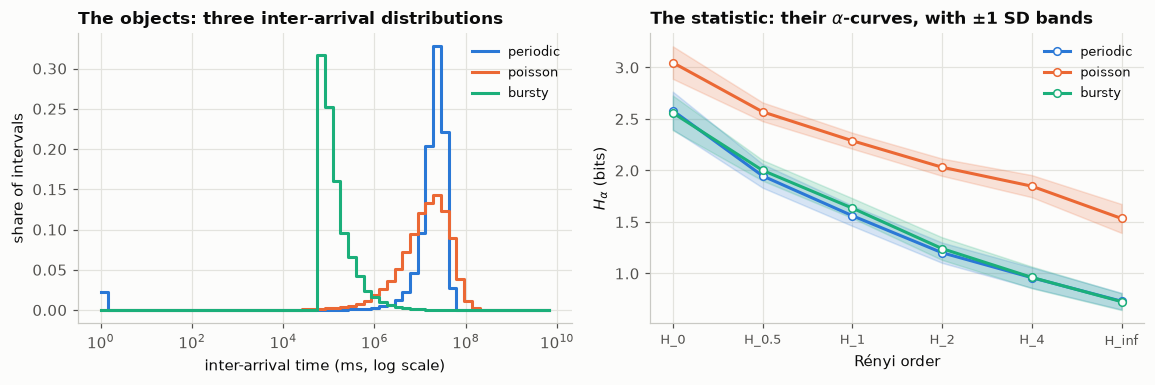

In [15]:
# --- The positive control, rendered: three known generators at matched n ---
# renyiext.generators produces periodic / Poisson / heavy-tailed accounts with
# IDENTICAL event counts, so event count carries zero information and anything
# that separates them is distributional shape.
N_EVENTS, N_PER_CLASS = 200, 60
series, y_gen, names = generate_control_set(n_per_class=N_PER_CLASS,
                                            n_events=N_EVENTS, rng=SEED,
                                            jitter=0.5, tail=1.2)
print(f"{len(series)} synthetic accounts, {N_EVENTS} events EACH -> count is uninformative")
print("generators:", names)

# G1: draw the OBJECT (the inter-arrival distributions), not just the statistic.
fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.6))

ax = axes[0]
edges = np.logspace(0, 10, 60)
for gi, (name, col) in enumerate(zip(names, SERIES)):
    pooled = np.concatenate([s for s, k in zip(series, y_gen) if k == gi])
    h, _ = np.histogram(pooled, bins=edges)
    ax.step(edges[:-1], h / h.sum(), where="post", color=col, label=name)
ax.set_xscale("log"); ax.set_xlabel("inter-arrival time (ms, log scale)")
ax.set_ylabel("share of intervals")
ax.set_title("The objects: three inter-arrival distributions")
ax.legend(fontsize=8.5)

# G1b: and now the statistic computed from them.
ax = axes[1]
ax_x = np.arange(len(SPECTRUM_ALPHAS))
for gi, (name, col) in enumerate(zip(names, SERIES)):
    S = np.array([spectrum(counts_to_probabilities(
                      log_bin_counts(s, n_bins=24, lo=1.0, hi=400 * 86_400_000.0)),
                      SPECTRUM_ALPHAS)
                  for s, k in zip(series, y_gen) if k == gi])
    m, sd = S.mean(0), S.std(0)
    ax.plot(ax_x, m, "o-", color=col, ms=5, mfc="#fcfcfb", label=name)
    ax.fill_between(ax_x, m - sd, m + sd, color=col, alpha=0.18)
ax.set_xticks(ax_x); ax.set_xticklabels(spectrum_labels(SPECTRUM_ALPHAS), fontsize=8.5)
ax.set_xlabel("Rényi order"); ax.set_ylabel("$H_\\alpha$ (bits)")
ax.set_title("The statistic: their $\\alpha$-curves, with $\\pm$1 SD bands")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

In [16]:
# --- How much of the separation is level, and how much is shape? ----------
# Decompose each curve into its LEVEL (H_1) and its SHAPE (H_alpha - H_1).
curves = {}
for gi, name in enumerate(names):
    S = np.array([spectrum(counts_to_probabilities(
                      log_bin_counts(s, n_bins=24, lo=1.0, hi=400 * 86_400_000.0)),
                      SPECTRUM_ALPHAS)
                  for s, k in zip(series, y_gen) if k == gi])
    curves[name] = S

lab = spectrum_labels(SPECTRUM_ALPHAS)
LEVEL = pd.DataFrame({n: [S.mean(0)[lab.index("H_1")]] for n, S in curves.items()},
                     index=["level (H_1), bits"])
SHAPE = pd.DataFrame({n: (S.mean(0) - S.mean(0)[lab.index("H_1")]) for n, S in curves.items()},
                     index=lab)
print("Level -- where each curve sits:")
print(LEVEL.round(3).to_string())
print("\nShape -- each curve after its own level is subtracted:")
print(SHAPE.round(3).to_string())
print()
print("Pairwise separation, level vs shape (mean absolute difference across orders):")
ns = list(curves)
for i in range(len(ns)):
    for j in range(i + 1, len(ns)):
        dl = abs(LEVEL[ns[i]].iloc[0] - LEVEL[ns[j]].iloc[0])
        dsh = float(np.abs(SHAPE[ns[i]] - SHAPE[ns[j]]).mean())
        print(f"  {ns[i]:>8} vs {ns[j]:<8}  level {dl:.3f} bits   shape {dsh:.3f} bits")

Level -- where each curve sits:
                   periodic  poisson  bursty
level (H_1), bits     1.561    2.289   1.635

Shape -- each curve after its own level is subtracted:
       periodic  poisson  bursty
H_0       1.020    0.759   0.925
H_0.5     0.387    0.281   0.366
H_1       0.000    0.000   0.000
H_2      -0.359   -0.257  -0.393
H_4      -0.601   -0.441  -0.673
H_inf    -0.830   -0.755  -0.908

Pairwise separation, level vs shape (mean absolute difference across orders):
  periodic vs poisson   level 0.728 bits   shape 0.118 bits
  periodic vs bursty    level 0.074 bits   shape 0.050 bits
   poisson vs bursty    level 0.654 bits   shape 0.129 bits


**Figure 3.** Left, the objects; right, the statistic computed from them. The
three generators' curves **do separate** — the positive control passes, so the
estimator is not simply reading volume (every account here has exactly 200
events). But look at *how* they separate: largely as a **vertical offset**, with
broadly similar slope. That is the same reading the real corpus gave.

Two details in that figure are worth naming rather than glossing. At these hard
settings the **periodic and bursty curves nearly coincide** — the printed
decomposition puts them 0.074 bits apart in level and 0.050 in shape — while
Poisson sits clearly above both. So the control passes as a three-way separation
largely because *one* of the three is distinguishable, which is a weaker result
than "the spectrum tells the three regimes apart" would suggest.

*(The generator settings — jitter 0.5, Pareto tail 1.2 — are the deliberately
**hard** defaults. At the easy settings all three separate perfectly and so does
Shannon alone, which is a control that licenses nothing. §5.3.)*

### But shape is not nothing — the decomposition that rescues a weaker claim

On the real corpus, the bitácora ran the honest follow-up: remove the level
entirely (subtract $H_1$ from every order, leaving only the curve's shape) and
re-run.

In [17]:
# --- Verified constants: the level/shape decomposition ---------------------
# Source: bitacora/04_p2_temporal.md sect. 4, "But shape is not nothing".
DECOMP = pd.DataFrame([
    ("SPEC_T (full)",              0.9699),
    ("SPEC_T minus H_0",           0.9594),
    ("SHAPE only, level removed",  0.9596),
    ("COUNT + SHAPE",              0.9673),
], columns=["arm", "auc"])
DECOMP_TESTS = pd.DataFrame([
    ("COUNT+SHAPE  vs  COUNT",           0.0273, "CLEARS"),
    ("SPEC_T  vs  SPEC_T-minus-H_0",     0.0104, "fails"),
], columns=["comparison", "delta_auc", "verdict"])
print(f"majority baseline {P2_MAJORITY:.4f}\n")
print(DECOMP.to_string(index=False))
print()
print(DECOMP_TESTS.to_string(index=False), "   (floor 0.02)")
print()
print("The alpha-curve's SHAPE alone, with all level information destroyed, clears")
print("the count floor at +0.0273. So the curves are less parallel than the eye")
print("reads, and there is genuine shape information.")
print()
print("Equally: H_0 -- the single most volume-contaminated order -- contributes only")
print("+0.0104 of the spectrum's edge, so the result does not rest on the order most")
print("exposed to the volume risk.")

majority baseline 0.5966

                      arm    auc
            SPEC_T (full) 0.9699
         SPEC_T minus H_0 0.9594
SHAPE only, level removed 0.9596
            COUNT + SHAPE 0.9673

                  comparison  delta_auc verdict
      COUNT+SHAPE  vs  COUNT     0.0273  CLEARS
SPEC_T  vs  SPEC_T-minus-H_0     0.0104   fails    (floor 0.02)

The alpha-curve's SHAPE alone, with all level information destroyed, clears
the count floor at +0.0273. So the curves are less parallel than the eye
reads, and there is genuine shape information.

Equally: H_0 -- the single most volume-contaminated order -- contributes only
+0.0104 of the spectrum's edge, so the result does not rest on the order most
exposed to the volume risk.


**Net reading of the mechanism, stated as the bitácora states it:** the
separation is *mostly* level (which is largely volume) plus a *real but modest*
shape component. **H1's specific tail-resolution mechanism is not
demonstrated**; something weaker and less interesting — that the α-profile
carries information beyond one entropy and beyond a count — is.

### An anomaly, flagged and deliberately not interpreted

Partial correlation with the label, given log count, **reverses sign** for every
*circadian* order ($H_0$: −0.425 → +0.268; $H_1$: −0.273 → +0.269; $H_\infty$:
−0.257 → +0.207). The inter-arrival orders do not reverse (−0.72 → −0.22:
attenuated, same sign).

A sign reversal under conditioning is a suppression effect and can be real or an
artefact of linear partialling. It is recorded as **exploratory and not
interpreted** — it was not predicted, is not part of H1, and needs its own render
(the circadian histograms of matched-count bots and humans, side by side) before
anything is said about it.

Resisting the urge to explain that is the same discipline as everything else in
this notebook.

---

## 7. Where it stands

| Phase | Name | Gate | Status |
|---|---|---|---|
| P0 | Data layer and event reconstruction | 2.83M timestamps decoded, sanity checks | **FAIL** — on `n_events`; forced the H1 amendment |
| P1 | Rényi spectrum estimator | property checks + bias control | **PASS** 8/8 |
| P2 | Temporal front | H1 | **PASS** (H1) / burstiness floor **not cleared** |
| P3 | Behavioural and text fronts | incremental AUC over P2 | not started |
| P4 | Digital DNA, BDM 1.0, NCD | H3, beats gzip and block entropy | not started |
| P5 | Network front (TwiBot-20) | permutation + configuration-model controls | not started |
| P6 | **Cross-dataset generalisation** | **H4 — the primary claim** | not started |
| P7 | BDM 2.0, Tiers 1–2 | reuse gain beats NCD | not started |
| P8 | Conditional CTM (optional) | only if P7 passes | not started |
| P9 | Write-up and artefacts | notebook reproduces every figure | not started |

**Three things carried into P3**, straight from the bitácora:

1. **BURST is now a first-class floor in every subsequent front**, not just the
   temporal one. It was the binding comparison and it was nearly missed.
2. **The level/shape decomposition becomes a standard arm.** It is the cleanest
   separation of "shape" from "magnitude" this project has, and it is what the
   charter's motivation actually claims.
3. **H4 remains primary, and P2 is a reason to expect it to be *harder*, not
   easier.** SPEC_T's advantage here is partly *level*, and level is
   corpus-specific.

That last point deserves emphasis. The natural move after a passing gate is to
read it as encouragement for the primary claim. The bitácora reads it the other
way, and gives the reason.

### A note on the one number that has nothing to do with entropy

`HistGradientBoostingClassifier` took **115.6 s** for 5 folds of 4,770 × 12 with
the default OpenMP pool, and **0.87 s** pinned to one thread — a **133×** penalty,
entirely scheduling overhead. It is recorded because a 133× penalty invisible in
the output is exactly the kind of thing that quietly caps how many seeds and
sweep points an experiment gets, and therefore how much evidence it can produce.

It is also why every notebook in this series sets `OMP_NUM_THREADS=1` before its
first import.

## What this licenses

- **H1 is supported as pre-registered**, on Cresci-2015's temporal front: clause (i) +0.0367, clause (ii) +0.0380, 10/10 seeds, paired Wilcoxon p = 0.0020, stable across all 14 swept configurations. Majority baseline 0.5966.
- The operational claim: at FPR = 1%, COUNT recovers 0.141 of bots and SPEC_T recovers 0.779 — a 5.5× difference in the deployment regime.
- **The burstiness floor is NOT cleared.** Twelve Rényi orders add **+0.019** over three classical burstiness numbers, below the pre-registered 0.02 floor. This is reported as a failure, per the protocol, and it is the finding a reader should carry.
- The α-curves are near-parallel, no single order beats volume, and every order correlates 0.66–0.82 with log count. **H1's stated tail-resolution mechanism is not demonstrated.** A weaker claim survives: shape alone, with the level destroyed, clears the count floor at +0.0273.
- The snowflake decode (D1) stands: 0 violations / 2,763,927 elementwise, and it separates from a counter null (circadian peak/trough 12.82 vs 1.00). 63,830 pre-snowflake ids were excluded under D9.
- The estimator satisfies 8 of 8 stated properties, and its finite-sample bias is measured (H₀ drifts 1.314 bits from n = 8 to n = 4096 on a fixed distribution) rather than corrected.

## What this does NOT license

- *"The Rényi spectrum is a better bot detector."* It is not shown to be worth its dimensionality against burstiness — the incumbent that matters. That floor was not cleared.
- *"Bots differ from humans in the tail of their inter-arrival distribution."* The render does not support it. The separation is mostly a vertical offset, and the offset is largely volume.
- **Anything about AI-generated text.** Every corpus here is 2015–2022 and carries no ground truth for machine-generated text. This is an explicit non-goal (`docs/00-CHARTER.md` §4, non-goal 1); an earlier framing of this work drifted there and was ruled out on the record.
- *"H4 is on track."* H4 — cross-dataset transfer, the **primary** claim — has not been tested. P2 is a reason to expect it to be harder, since SPEC_T's advantage is partly corpus-specific level.
- Any claim about corpora not measured. Everything here is Cresci-2015; TwiBot-20's volume confound is unmeasured, and TwiBot-22's graph and tweets are not in the open release.
- *"The three papers are wrong."* Two of three replications reproduce their headline numbers closely. The findings are that the published **comparisons** do not isolate what they claim to isolate — and this project has now had the same thing said about one of its own.

---

## Where to go next

| To | Read |
|---|---|
| check any number in this series | `01-info-propagation/overview/EVIDENCE-INDEX.md` |
| the findings in full | `01-info-propagation/overview/01-FINDINGS.md` |
| the pre-registered design | `02-ext-research/docs/00-CHARTER.md`, then `02-PROTOCOL.md` |
| what actually happened, in order | `02-ext-research/bitacora/00` → `04` |
| the standing rules | `02-ext-research/docs/06-STANDING-RULES.md` |

**The five transferable lessons**, which are the reason this series exists:

1. **Measure the noise floor before reading any sweep.** (F3)
2. **Ablate against your own novelty, not against unrelated baselines.** (F4 —
   and §6.2, where it happened to us.)
3. **Print the majority baseline.** (F5)
4. **Name the protocol on every number.** (F5)
5. **Look at the object before quoting a statistic of it.** (§3.)